In [1]:
from scipy.io import loadmat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter,lfilter,freqz



pd.reset_option('max_columns')

In [2]:
data_thumb = pd.read_csv('Extracted Data\\data_1.csv')
angle_thumb = pd.read_csv('Extracted Data\\data_1_ang.csv')

data_index = pd.read_csv('Extracted Data\\data_2.csv')
angle_index = pd.read_csv('Extracted Data\\data_2_ang.csv')

data_middle = pd.read_csv('Extracted Data\\data_3.csv')
angle_middle = pd.read_csv('Extracted Data\\data_3_ang.csv')

data_ring = pd.read_csv('Extracted Data\\data_4.csv')
angle_ring = pd.read_csv('Extracted Data\\data_4_ang.csv')

data_pinky = pd.read_csv('Extracted Data\\data_5.csv')
angle_pinky = pd.read_csv('Extracted Data\\data_5_ang.csv')

data_2f = pd.read_csv('Extracted Data\\data_6.csv')
angle_2f = pd.read_csv('Extracted Data\\data_6_ang.csv')

data_4f = pd.read_csv('Extracted Data\\data_7.csv')
angle_4f = pd.read_csv('Extracted Data\\data_7_ang.csv')

data_cup1 = pd.read_csv('Extracted Data\\data_8.csv')
angle_cup1 = pd.read_csv('Extracted Data\\data_8_ang.csv')

data_cup2 = pd.read_csv('Extracted Data\\data_9.csv')
angle_cup2 = pd.read_csv('Extracted Data\\data_9_ang.csv')

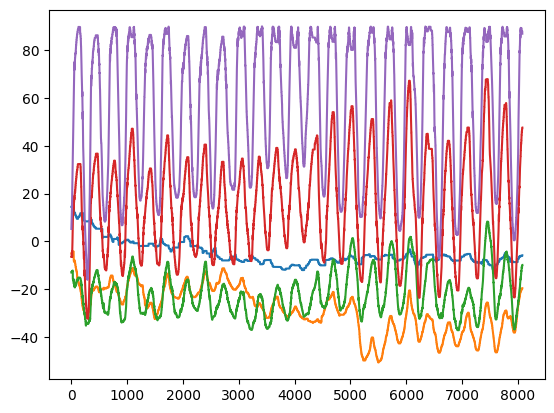

In [3]:
plt.plot(angle_pinky)

In [4]:
import numpy as np
import pandas as pd
import scipy.signal as signal

def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = signal.butter(order, [low, high], btype='band')
    y = signal.filtfilt(b, a, data)
    return y

def filter_emg_columns(df, emg_columns, lowcut, highcut, fs):
    for col in emg_columns:
        df[col] = butter_bandpass_filter(df[col], lowcut, highcut, fs)
    return df

# Define parameters
fs = 1259  # Sampling frequency (Hz)
lowcut = 10  # Low cutoff frequency (Hz)
highcut = 450  # High cutoff frequency (Hz)

# EMG and angle columns
emg_columns = [f'Trigno_Avanti_Sensor{i}_EMG_1' for i in range(1,15)] # Assuming columns are named EMG_0, EMG_1, ..., EMG_15

# Apply filtering to all three DataFrames
train_th = filter_emg_columns(data_thumb, emg_columns, lowcut, highcut, fs)
train_in = filter_emg_columns(data_index, emg_columns, lowcut, highcut, fs)
train_mi = filter_emg_columns(data_middle, emg_columns, lowcut, highcut, fs)
train_ri = filter_emg_columns(data_ring, emg_columns, lowcut, highcut, fs)
train_pi = filter_emg_columns(data_pinky, emg_columns, lowcut, highcut, fs)
train_2f = filter_emg_columns(data_2f, emg_columns, lowcut, highcut, fs)
train_4f = filter_emg_columns(data_4f, emg_columns, lowcut, highcut, fs)
train_cup1 = filter_emg_columns(data_cup1, emg_columns, lowcut, highcut, fs)
train_cup2 = filter_emg_columns(data_cup2, emg_columns, lowcut, highcut, fs)

In [5]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

def upsampling(emg,angle):
# Example data preparation
    emg_df = emg # Placeholder for your EMG data
    angle_df = angle  # Placeholder for your angle data

    # Define the x-values for interpolation
    x_original = np.arange(len(angle_df))
    x_new = np.linspace(0, len(angle_df) - 1, num=len(emg_df))

    # Perform interpolation for each column
    angle_upsampled = np.zeros((len(emg_df), angle_df.shape[1]))
    for i in range(angle_df.shape[1]):
        f = interp1d(x_original, angle_df.iloc[:, i], kind='quadratic', fill_value="extrapolate")
        angle_upsampled[:, i] = f(x_new)

    # Convert the upsampled data into a DataFrame
    angle_upsampled_df = pd.DataFrame(angle_upsampled, columns=angle_df.columns)

    return angle_upsampled_df

angle_upsampled_th = upsampling(train_th,angle_thumb)
angle_upsampled_in = upsampling(train_in,angle_index)
angle_upsampled_mi = upsampling(train_mi,angle_middle)
angle_upsampled_ri = upsampling(train_ri,angle_ring)
angle_upsampled_pi = upsampling(train_pi,angle_pinky)
angle_upsampled_2f = upsampling(train_2f,angle_2f)
angle_upsampled_4f = upsampling(train_4f,angle_4f)
angle_upsampled_c1 = upsampling(train_cup1,angle_cup1)
angle_upsampled_c2 = upsampling(train_cup2,angle_cup2)

In [6]:
thumb = pd.concat([train_th, angle_upsampled_th], axis=1)
index = pd.concat([train_in, angle_upsampled_in], axis=1)
middle = pd.concat([train_mi, angle_upsampled_mi], axis=1)
ring = pd.concat([train_ri,  angle_upsampled_ri], axis=1)
pinky = pd.concat([train_pi, angle_upsampled_pi], axis=1)
finger2 = pd.concat([train_2f, angle_upsampled_2f], axis=1)
finger4 = pd.concat([train_4f, angle_upsampled_4f], axis=1)
cup1 = pd.concat([train_cup1, angle_upsampled_c1], axis=1)
cup2 = pd.concat([train_cup2, angle_upsampled_c2], axis=1)

In [7]:

def train_split(data):
    total_samples = len(data)

    # Calculate split indices
    train_size = int(0.7 * total_samples)  # 70% for training
    val_size = int(0.20 * total_samples)    # 20% for validation
    test_size = total_samples - train_size - val_size  # Remaining 10% for testing

    train_data = data.iloc[:train_size]  # First 70% for training
    val_data = data.iloc[train_size:train_size + val_size]  # Next 20% for validation
    test_data = data.iloc[train_size + val_size:]  # Last 10% for testing

    return train_data,val_data,test_data

train_data_th,val_data_th,test_data_th = train_split(thumb)
train_data_in,val_data_in,test_data_in = train_split(index)
train_data_mi,val_data_mi,test_data_mi = train_split(middle)
train_data_ri,val_data_ri,test_data_ri = train_split(ring)
train_data_pi,val_data_pi,test_data_pi = train_split(pinky)
train_data_2f,val_data_2f,test_data_2f = train_split(finger2)
train_data_4f,val_data_4f,test_data_4f = train_split(finger4)
train_data_c1,val_data_c1,test_data_c1 = train_split(cup1)
train_data_c2,val_data_c2,test_data_c2 = train_split(cup2)

In [8]:
train_data = pd.concat([train_data_th,train_data_in,train_data_mi,train_data_ri,train_data_pi,train_data_2f,train_data_4f,train_data_c1,train_data_c2],axis=0)
val_data = pd.concat([val_data_th,val_data_in,val_data_mi,val_data_ri,val_data_pi,val_data_2f,val_data_4f,val_data_c1,val_data_c2],axis=0)
test_data = pd.concat([test_data_th,test_data_in,test_data_mi,test_data_ri,test_data_pi,test_data_2f,test_data_4f,test_data_c1,test_data_c2],axis=0)

train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

In [9]:
train_data['emg_var'] = train_data[emg_columns].var(axis = 1)
train_data['emg_mean'] = train_data[emg_columns].mean(axis=1)
train_data['median'] = train_data[emg_columns].median(axis=1)

val_data['emg_mean'] = val_data[emg_columns].mean(axis=1)
val_data['emg_var'] = val_data[emg_columns].var(axis = 1)
val_data['median'] = val_data[emg_columns].median(axis=1)

test_data['emg_mean'] = test_data[emg_columns].mean(axis=1)
test_data['emg_var'] = test_data[emg_columns].var(axis = 1)
test_data['median'] = test_data[emg_columns].median(axis=1)

In [10]:
first_column_train = train_data.pop('emg_mean')
train_data.insert(0, 'emg_mean', first_column_train) 
second_column_train = train_data.pop('emg_var')
train_data.insert(0, 'emg_var', second_column_train) 
third_column_train = train_data.pop('median')
train_data.insert(0, 'median', third_column_train) 

first_column_val = val_data.pop('emg_mean')
val_data.insert(0, 'emg_mean', first_column_val) 
second_column_val = val_data.pop('emg_var')
val_data.insert(0, 'emg_var', second_column_val) 
third_column_val = val_data.pop('median')
val_data.insert(0, 'median', third_column_val) 


first_column_test = test_data.pop('emg_mean')
test_data.insert(0, 'emg_mean', first_column_test) 
second_column_test = test_data.pop('emg_var')
test_data.insert(0, 'emg_var', second_column_test) 
third_column_test = test_data.pop('median')
test_data.insert(0, 'median', third_column_test) 

In [11]:
mrmr_test = train_data.drop(["Thumb","Index","Ring","Pinky"],axis =1)
first_column_mrmr = mrmr_test.pop('Middle')
mrmr_test.insert(0, 'Middle', first_column_mrmr) 
display(mrmr_test)

,Middle,median,emg_var,emg_mean,Trigno_Avanti_Sensor1_EMG_1,Trigno_Avanti_Sensor1_ACC_X,Trigno_Avanti_Sensor1_ACC_Y,Trigno_Avanti_Sensor1_ACC_Z,Trigno_Avanti_Sensor1_GYRO_X,Trigno_Avanti_Sensor1_GYRO_Y,...,Trigno_Avanti_Sensor14_GYRO_X,Trigno_Avanti_Sensor14_GYRO_Y,Trigno_Avanti_Sensor14_GYRO_Z,Trigno_Avanti_Sensor13_EMG_1,Trigno_Avanti_Sensor13_ACC_X,Trigno_Avanti_Sensor13_ACC_Y,Trigno_Avanti_Sensor13_ACC_Z,Trigno_Avanti_Sensor13_GYRO_X,Trigno_Avanti_Sensor13_GYRO_Y,Trigno_Avanti_Sensor13_GYRO_Z
0,-14.043798,0.040353,1.178347,-0.512861,0.040534,-7.273585,-5.161899,3.706224,-3.170732,-12.682927,...,-1.280488,-14.329268,1.951220,-0.820789,7.335834,-5.679047,2.413355,10.731708,5.365854,0.853659
1,-14.043868,-1.248981,23.471039,-1.520611,3.175611,-7.273585,-5.161899,3.706224,-3.170732,-12.682927,...,-1.280488,-14.329268,1.951220,-12.999875,7.335834,-5.679047,2.413355,10.731708,5.365854,0.853659
2,-14.043931,-2.061830,197.837860,-4.751934,-2.169141,-7.273585,-5.161899,3.706224,-3.170732,-12.682927,...,-1.280488,-14.329268,1.951220,-49.746140,7.335834,-5.679047,2.413355,10.731708,5.365854,0.853659
3,-14.043985,-3.344996,530.837843,-7.393869,-4.401211,-7.244854,-5.118803,3.667917,-3.109756,-12.256098,...,-1.646341,-14.146341,2.012195,-84.178620,7.354988,-5.631162,2.418144,10.914635,5.000000,0.853659
4,-14.044032,-1.115074,419.894748,-5.432609,-0.697244,-7.244854,-5.118803,3.667917,-3.109756,-12.256098,...,-1.646341,-14.146341,2.012195,-72.420966,7.354988,-5.631162,2.418144,10.914635,5.000000,0.853659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216468,-22.466042,-1.057364,1279.720915,6.871704,-4.643002,-7.790732,-1.508347,4.975151,-2.987805,-13.292684,...,5.731708,-17.439024,3.292683,6.954520,8.796297,-2.518700,2.920926,10.792684,-1.768293,-1.585366
216469,-22.618190,-8.119589,2768.832620,3.770610,-4.280585,-7.790732,-1.508347,4.975151,-2.987805,-13.292684,...,5.731708,-17.439024,3.292683,103.429202,8.796297,-2.518700,2.920926,10.792684,-1.768293,-1.585366
216470,-22.801396,-18.152557,3851.545059,-0.878098,-4.463903,-7.790732,-1.508347,4.975151,-2.987805,-13.292684,...,5.731708,-17.439024,3.292683,144.715404,8.796297,-2.518700,2.920926,10.792684,-1.768293,-1.585366
216471,-23.011159,-24.611057,1327.705104,-20.461505,-2.924869,-7.666234,-1.532289,5.085284,-3.414634,-14.085366,...,5.914634,-18.048780,3.292683,-68.628498,8.815451,-2.561796,2.801216,11.890244,-0.365854,-2.012195


In [12]:
import pymrmr

# Combine features and target into a single DataFrame for mRMR
# mRMR requires the target variable to be included in the DataFrame


# Apply mRMR feature selection
# 'MID' stands for Mutual Information Difference (supervised mRMR)
# You can also use 'MIQ' (Mutual Information Quotient)
selected_features = pymrmr.mRMR(mrmr_test, 'MID', 18)  # Select top 10 features

print("Selected features:", selected_features)

Selected features: ['emg_var', 'Trigno_Avanti_Sensor6_ACC_Y', 'Trigno_Avanti_Sensor11_ACC_X', 'Trigno_Avanti_Sensor5_ACC_X', 'Trigno_Avanti_Sensor4_ACC_Y', 'Trigno_Avanti_Sensor5_ACC_Z', 'Trigno_Avanti_Sensor14_ACC_Z', 'Trigno_Avanti_Sensor13_ACC_Z', 'Trigno_Avanti_Sensor14_ACC_Y', 'Trigno_Avanti_Sensor7_ACC_X', 'Trigno_Avanti_Sensor3_ACC_Z', 'Trigno_Avanti_Sensor13_ACC_Y', 'Trigno_Avanti_Sensor7_ACC_Z', 'Trigno_Avanti_Sensor11_ACC_Z', 'Trigno_Avanti_Sensor13_EMG_1', 'Trigno_Avanti_Sensor3_EMG_1', 'Trigno_Avanti_Sensor11_ACC_Y', 'Trigno_Avanti_Sensor8_ACC_Z']


In [11]:
selected_features =  ['emg_var', 'Trigno_Avanti_Sensor5_ACC_X', 'Trigno_Avanti_Sensor5_ACC_Z', 'Trigno_Avanti_Sensor5_EMG_1', 'Trigno_Avanti_Sensor1_ACC_Z', 'Trigno_Avanti_Sensor14_ACC_X', 'Trigno_Avanti_Sensor4_ACC_Y', 'Trigno_Avanti_Sensor11_ACC_Z', 'Trigno_Avanti_Sensor7_ACC_Z', 'Trigno_Avanti_Sensor12_ACC_Z', 'Trigno_Avanti_Sensor2_ACC_Z', 'Trigno_Avanti_Sensor14_ACC_Z', 'Trigno_Avanti_Sensor13_ACC_X', 'Trigno_Avanti_Sensor8_ACC_Z', 'Trigno_Avanti_Sensor3_ACC_Y', 'Trigno_Avanti_Sensor11_ACC_X', 'Trigno_Avanti_Sensor9_GYRO_X', 'Trigno_Avanti_Sensor4_GYRO_X']

In [12]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, MultiHeadAttention, LayerNormalization, GlobalAveragePooling2D, Reshape, GlobalAveragePooling1D
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import tensorflow.keras.backend as K


# -----------------------------
# Data Loading & Preprocessing
# -----------------------------
# Assuming you have pca_train, pca_val, pca_test, selected_features already defined
X_train = train_data[selected_features]
y_train = train_data.iloc[:, -5:]

X_val = val_data[selected_features]
y_val = val_data.iloc[:, -5:]

X_test = test_data[selected_features]
y_test = test_data.iloc[:, -5:]

# Normalize features and targets
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)

# Define windowing function
def create_windows(data, window_size, overlap):
    windows = []
    for i in range(0, len(data) - window_size + 1, overlap):
        windows.append(data[i:i + window_size])
    return np.array(windows)

window_size = 150
overlap = 25

X_train_windows = create_windows(X_train_scaled, window_size, overlap)
y_train_windows = create_windows(y_train_scaled, window_size, overlap)

X_val_windows = create_windows(X_val_scaled, window_size, overlap)
y_val_windows = create_windows(y_val_scaled, window_size, overlap)

X_test_windows = create_windows(X_test_scaled, window_size, overlap)
y_test_windows = create_windows(y_test_scaled, window_size, overlap)

# Reshape for CNN input
def reshape_to_2d(data):
    return np.expand_dims(data.transpose(0, 2, 1), axis=-1)

X_train_2d = reshape_to_2d(X_train_windows)
X_val_2d = reshape_to_2d(X_val_windows)
X_test_2d = reshape_to_2d(X_test_windows)

X_train_2d_thumb = X_train_2d 
X_val_2d_thumb = X_val_2d 
X_test_2d_thumb = X_test_2d

X_train_2d_fingers = X_train_2d 
X_val_2d_fingers = X_val_2d 
X_test_2d_fingers = X_test_2d

X_train_2d_ring_pinky = X_train_2d 
X_val_2d_ring_pinky = X_val_2d 
X_test_2d_ring_pinky = X_test_2d


# Aggregate target labels by mean per window
y_train_aggregated = np.mean(y_train_windows, axis=1)
y_val_aggregated = np.mean(y_val_windows, axis=1)
y_test_aggregated = np.mean(y_test_windows, axis=1)

# Split labels into three groups
y_train_thumb = y_train_aggregated[:, [0]]         # Thumb
y_train_fingers = y_train_aggregated[:, 1:3]       # Index, Middle
y_train_ring_pinky = y_train_aggregated[:, 3:]     # Ring, Pinky

y_val_thumb = y_val_aggregated[:, [0]]
y_val_fingers = y_val_aggregated[:, 1:3]
y_val_ring_pinky = y_val_aggregated[:, 3:]

y_test_thumb = y_test_aggregated[:, [0]]
y_test_fingers = y_test_aggregated[:, 1:3]
y_test_ring_pinky = y_test_aggregated[:, 3:]

def add_noise(data, noise_level=0.01):
    return data + np.random.normal(0, noise_level, data.shape)

X_train_noisy = add_noise(X_train_2d_ring_pinky)

# -----------------------------
# Transformer Encoder
# -----------------------------
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout):
    x = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x + inputs)

    y = Dense(ff_dim, activation='relu')(x)
    y = Dense(inputs.shape[-1])(y)
    y = Dropout(dropout)(y)
    y = LayerNormalization(epsilon=1e-6)(y + x)
    return y

# -----------------------------
# Build CNN + Transformer Model
# -----------------------------
def build_2d_cnn_transformer_model(input_shape, head_size, num_heads, ff_dim, num_layers, dropout, output_dim):
    inputs = Input(shape=input_shape)

    x = Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Conv2D(filters=256, kernel_size=(3, 3), activation='relu', padding='same')(x)
    x = GlobalAveragePooling2D()(x)

    x = Reshape((-1, 128))(x)

    for _ in range(num_layers):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(0.03))(x)
    x = Dropout(0.5)(x)
    outputs = Dense(output_dim)(x)

    return Model(inputs, outputs)

# -----------------------------
# Build Three Models
# -----------------------------
input_shape = (X_train_2d.shape[1], X_train_2d.shape[2], X_train_2d.shape[3])


ring_pinky_model = build_2d_cnn_transformer_model(
    input_shape=input_shape,
    head_size=256,
    num_heads=4,
    ff_dim=128,
    num_layers=4,
    dropout=0.3,
    output_dim=2
)

# -----------------------------
# Compile Each Model Separately
# -----------------------------
ring_pinky_model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=[tf.keras.metrics.R2Score()])

# -----------------------------
# Train All Models
# -----------------------------
early_stop = EarlyStopping(patience=15, restore_best_weights=True)



In [13]:
K.clear_session()
tf.keras.backend.clear_session()
tf.random.set_seed(42) 
print("Training Ring + Pinky Model...")
history_ring_pinky = ring_pinky_model.fit(
    X_train_noisy, y_train_ring_pinky,
    validation_data=(X_val_2d_ring_pinky, y_val_ring_pinky),
    epochs=200, batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

ring_pinky_model.save("model_ring_pinky.keras")


Training Ring + Pinky Model...
Epoch 1/200
133/133 ━━━━━━━━━━━━━━━━━━━━ 72s 487ms/step - loss: 2.7742 - r2_score: -4.3077 - val_loss: 2.2818 - val_r2_score: -0.0863
Epoch 2/200
133/133 ━━━━━━━━━━━━━━━━━━━━ 66s 491ms/step - loss: 2.2207 - r2_score: -0.6791 - val_loss: 1.9025 - val_r2_score: 0.3701
Epoch 3/200
133/133 ━━━━━━━━━━━━━━━━━━━━ 86s 523ms/step - loss: 1.8561 - r2_score: -0.3064 - val_loss: 1.5762 - val_r2_score: 0.5304
Epoch 4/200
133/133 ━━━━━━━━━━━━━━━━━━━━ 49s 364ms/step - loss: 1.5387 - r2_score: -0.1006 - val_loss: 1.2959 - val_r2_score: 0.6270
Epoch 5/200
133/133 ━━━━━━━━━━━━━━━━━━━━ 28s 212ms/step - loss: 1.2628 - r2_score: 0.1058 - val_loss: 1.0591 - val_r2_score: 0.6701
Epoch 6/200
133/133 ━━━━━━━━━━━━━━━━━━━━ 26s 197ms/step - loss: 1.0312 - r2_score: 0.2271 - val_loss: 0.8572 - val_r2_score: 0.7334
Epoch 7/200
133/133 ━━━━━━━━━━━━━━━━━━━━ 27s 206ms/step - loss: 0.8369 - r2_score: 0.3161 - val_loss: 0.6894 - val_r2_score: 0.7921
Epoch 8/200
133/133 ━━━━━━━━━━━━━━━━━━━

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step

--- R² Scores per Finger ---
Thumb: R² = 0.9352
Index: R² = 0.9151
Middle: R² = 0.5562
Ring: R² = 0.6907
Pinky: R² = 0.8747


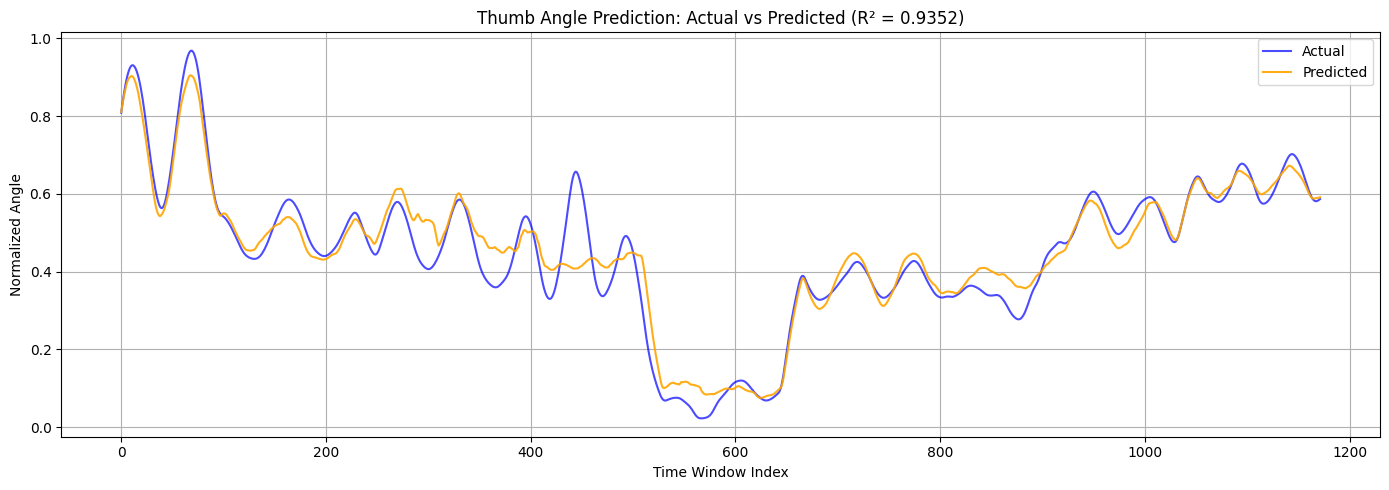

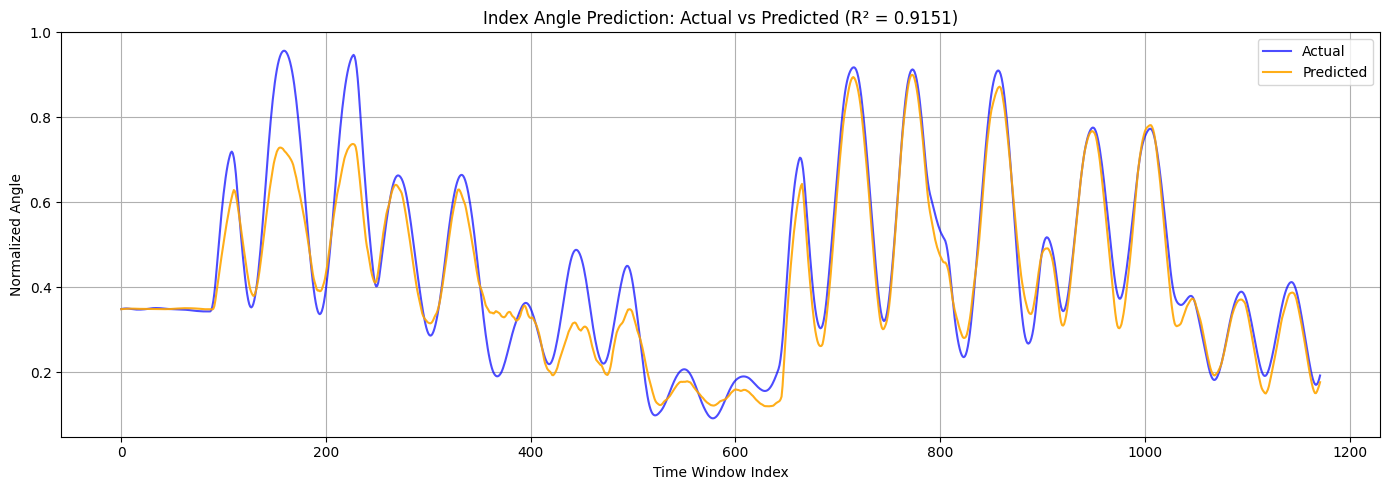

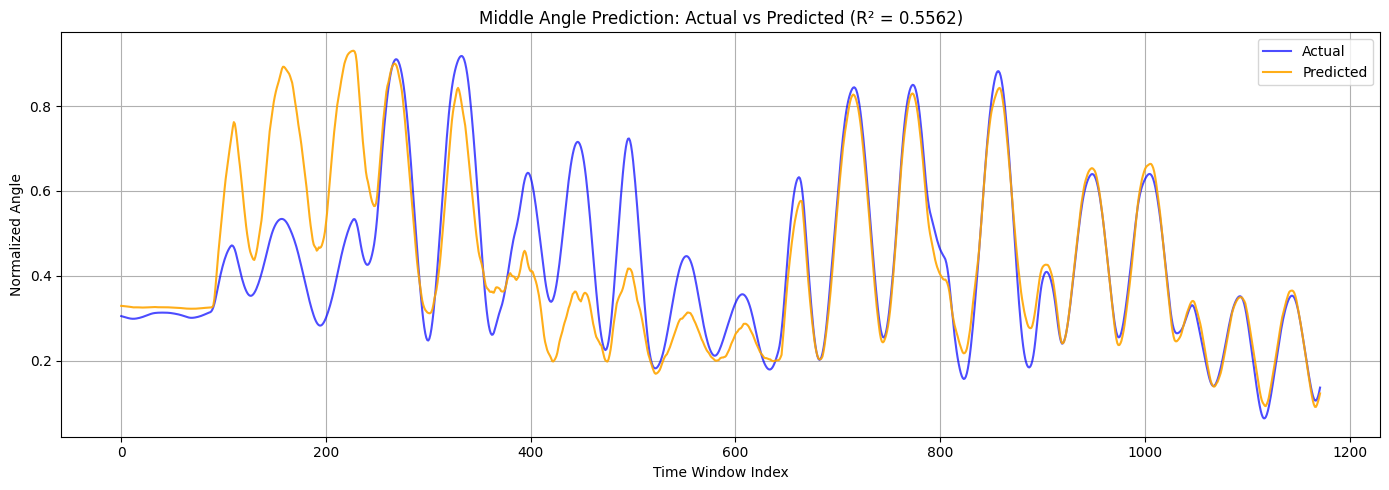

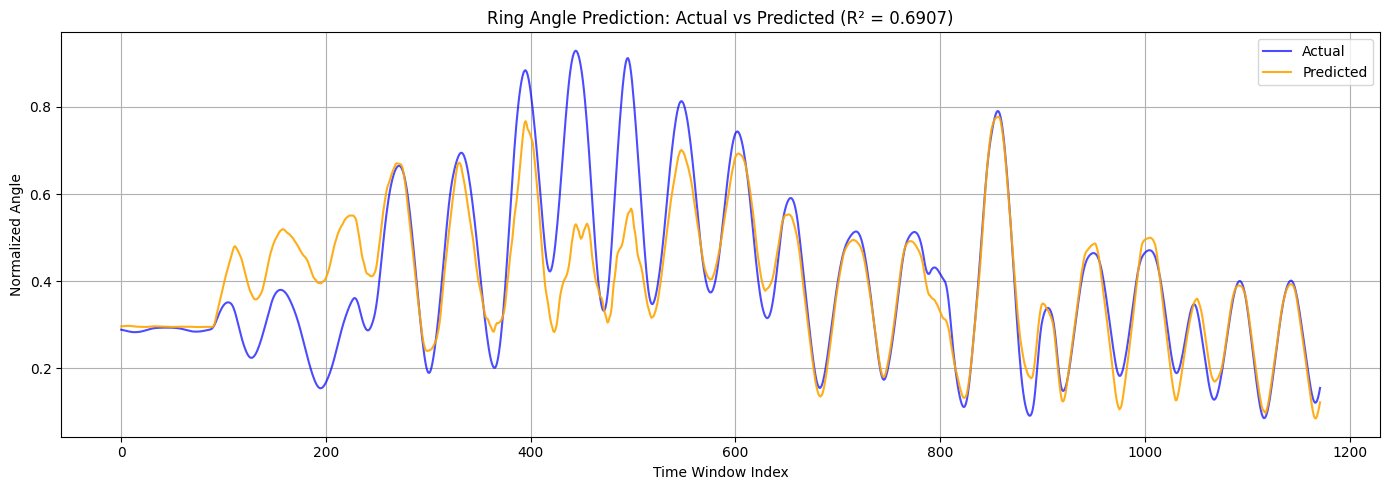

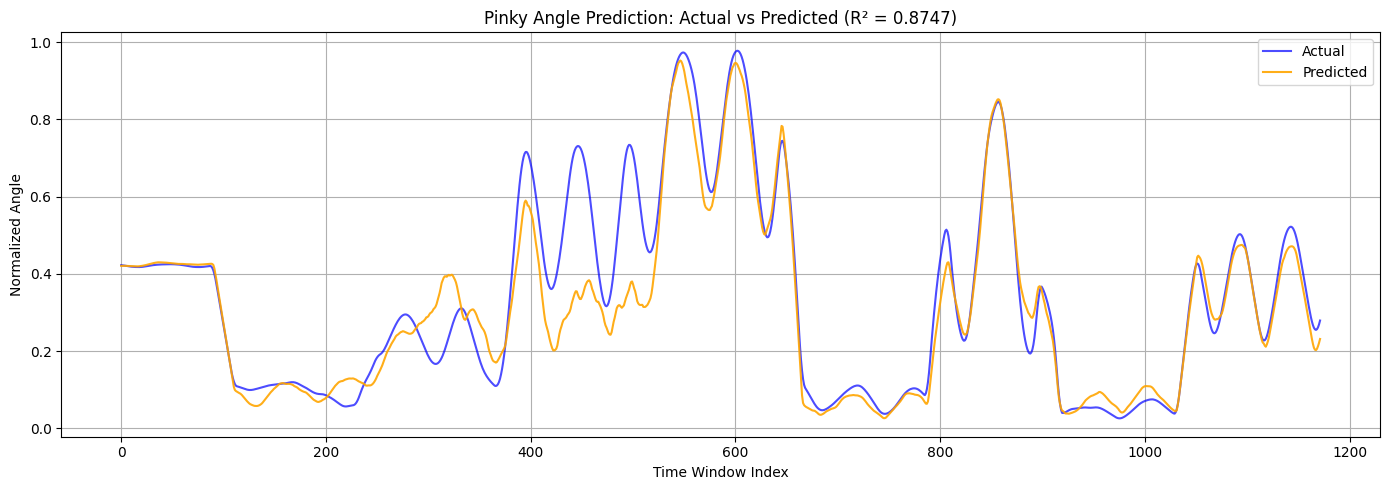

In [14]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import R2Score
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score


# -----------------------------
# Helper Functions
# -----------------------------
def moving_average(data, window_size):
    """Apply moving average smoothing."""
    smoothed = np.apply_along_axis(
        lambda x: np.convolve(x, np.ones(window_size)/window_size, mode='valid'),
        axis=0,
        arr=data
    )
    return smoothed

def align_smoothing_offset(true_data, pred_data, window_size):
    """Align shapes after smoothing"""
    offset = window_size - 1
    min_length = min(len(true_data) - offset, len(pred_data) - offset)
    true_aligned = true_data[offset : offset + min_length]
    pred_aligned = pred_data[offset : offset + min_length]
    return true_aligned, pred_aligned



# -----------------------------
# Load Saved Models
# -----------------------------

# Load and recompile thumb model
thumb_model = load_model("model_thumb.keras")
thumb_model.compile(optimizer='adam', loss='mse', metrics=[R2Score()])

# Load and recompile fingers model
fingers_model = load_model('model_fingers.keras')
fingers_model.compile(optimizer='adam', loss='mse', metrics=[R2Score()])

# Load and recompile ring + pinky model
ring_pinky_model = load_model('model_ring_pinky.keras')
ring_pinky_model.compile(optimizer='adam', loss='mse', metrics=[R2Score()])
# -----------------------------
# Make Predictions
# -----------------------------
thumb_pred = thumb_model.predict(X_test_2d_thumb)
fingers_pred = fingers_model.predict(X_test_2d_fingers)
ring_pinky_pred = ring_pinky_model.predict(X_test_2d_ring_pinky)

# Combine all predictions into one array [N, 5]
y_pred_combined = np.hstack([thumb_pred, fingers_pred, ring_pinky_pred])
y_true_combined = np.hstack([y_test_thumb, y_test_fingers, y_test_ring_pinky])

# -----------------------------
# Smoothing Predictions & True Labels
# -----------------------------
window_size_smooth = 20
smoothed_predictions = moving_average(y_pred_combined, window_size_smooth)
smoothed_true = moving_average(y_true_combined, window_size_smooth)

# Align shapes after smoothing
smoothed_true, smoothed_predictions = align_smoothing_offset(
    smoothed_true, smoothed_predictions, window_size_smooth
)

# -----------------------------
# Plot All Fingers
# -----------------------------
finger_names = ['Thumb', 'Index', 'Middle', 'Ring', 'Pinky']


print("\n--- R² Scores per Finger ---")
for i in range(5):
    r2 = r2_score(smoothed_true[:, i], smoothed_predictions[:, i])
    print(f"{finger_names[i]}: R² = {r2:.4f}")

for i in range(5):
    r2 = r2_score(smoothed_true[:, i], smoothed_predictions[:, i])
    plt.figure(figsize=(14, 5))
    plt.plot(smoothed_true[:, i], label='Actual', color='blue', alpha=0.7)
    plt.plot(smoothed_predictions[:, i], label='Predicted', color='orange', alpha=0.9)
    plt.title(f'{finger_names[i]} Angle Prediction: Actual vs Predicted (R² = {r2:.4f})')
    plt.xlabel('Time Window Index')
    plt.ylabel('Normalized Angle')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()